In [7]:
#High oxidized nitrogen = pollution.
#It can cause eutrophication (Algae blooms, Oxygen depletion in water, Fish and aquatic life die-offs)
#Unsafe for drinking at high levels → can cause health risks.

# Import pandas for data loading and manipulation
import pandas as pd

# Load the Oxidised Nitrogen dataset from a CSV file
nitrate_df = pd.read_csv('../data/oxidized_nitrogen.csv', sep=';', low_memory=False)  # handle mixed types warning

# Print the column names to understand the structure of the dataset
print(nitrate_df.columns)


Index(['GEMS.Station.Number', 'Sample.Date', 'Sample.Time', 'Depth',
       'Parameter.Code', 'Analysis.Method.Code', 'Value.Flags', 'Value',
       'Unit', 'Data.Quality'],
      dtype='object')


In [8]:
# Import Plotly Express for creating interactive visualizations
import plotly.express as px

# Load oxidized nitrogen data from CSV
nitrate_df = pd.read_csv('../data/oxidized_nitrogen.csv', sep=';', low_memory=False)

# Load station metadata, which contains country and location information
station_metadata = pd.read_csv('../data/GEMStat_station_metadata.csv', sep=';', encoding='ISO-8859-1')

# Clean column names by stripping extra spaces to ensure consistent naming
nitrate_df.columns = nitrate_df.columns.str.strip()
station_metadata.columns = station_metadata.columns.str.strip()

# Merge nitrate data with station metadata using the station number as the key
# (adds country-level info needed for mapping)
merged = pd.merge(nitrate_df, station_metadata, how='left', left_on='GEMS.Station.Number', right_on='GEMS Station Number')

# Group the merged data by country and calculate the mean oxidized nitrogen value
nitrate_by_country = merged.groupby('Country Name')['Value'].mean().reset_index()

# Create a choropleth map to visualize average oxidized nitrogen levels by country
fig = px.choropleth(
    nitrate_by_country,
    locations='Country Name',
    locationmode='country names',
    color='Value',
    color_continuous_scale='Viridis',
    title='Average Oxidized Nitrogen Levels by Country'
)

# Customize geographic projection and appearance
fig.update_geos(
    projection_type="natural earth",
    showcoastlines=True,
    showland=True,
    landcolor="LightGray"
)

# Display the interactive map in notebook or browser
fig.show()

# Save the map as an HTML file for sharing or web embedding
fig.write_html("../visualizations/nitrate_choropleth.html", include_plotlyjs='cdn')

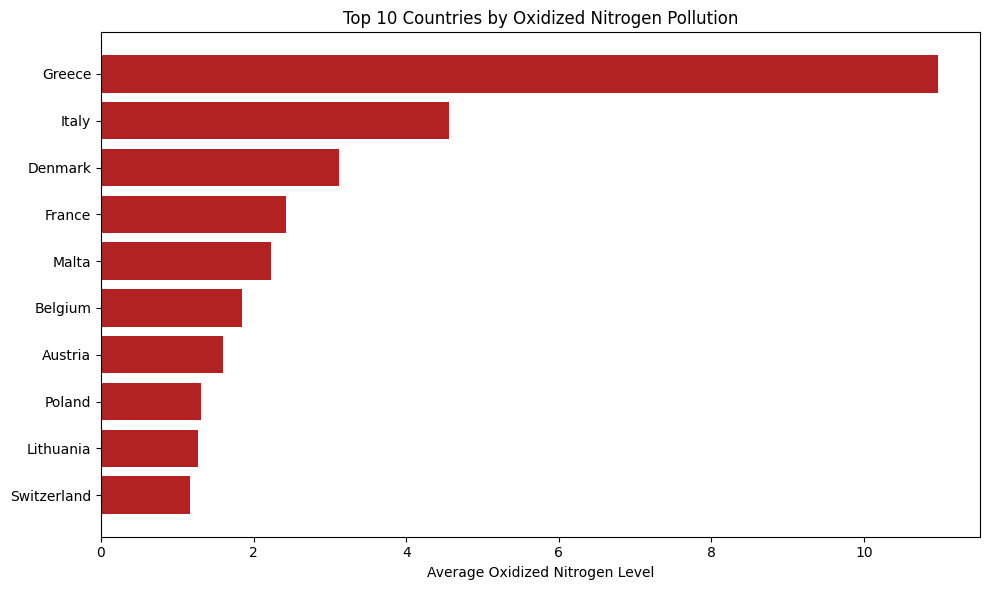

In [9]:
# Import matplotlib for creating static plots
import matplotlib.pyplot as plt

# Sort countries by highest average oxidized nitrogen levels and select the top 10
top10 = nitrate_by_country.sort_values(by='Value', ascending=False).head(10)

# Create a horizontal bar chart to visualize the top 10 most polluted countries
plt.figure(figsize=(10, 6))
plt.barh(top10['Country Name'], top10['Value'], color='firebrick')
plt.xlabel('Average Oxidized Nitrogen Level')
plt.title('Top 10 Countries by Oxidized Nitrogen Pollution')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


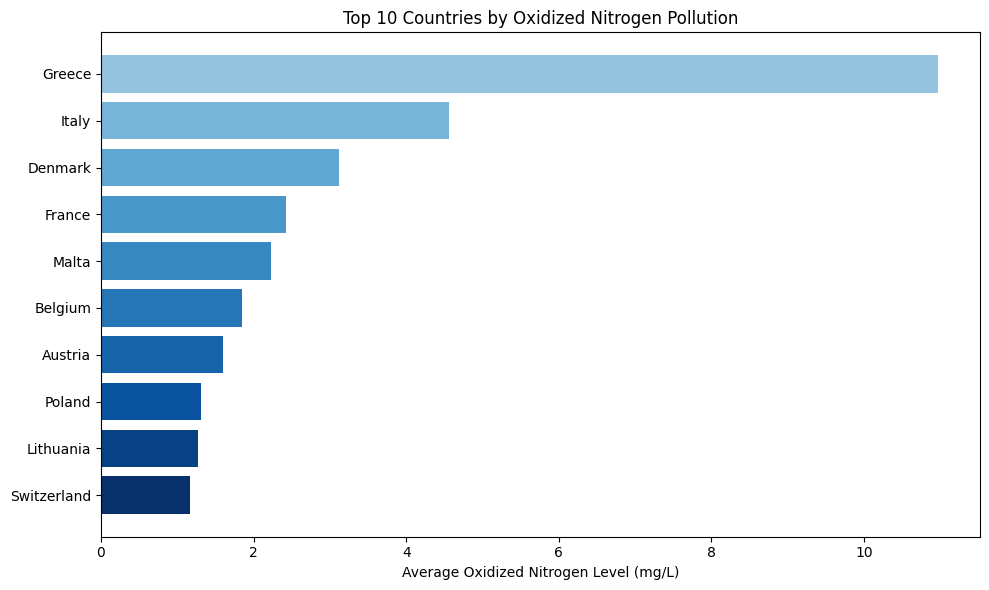

In [10]:
# For numerical operations
import numpy as np

# For colormap utilities
import matplotlib.cm as cm

# Select the top 10 countries with the highest average oxidized nitrogen levels
top10 = nitrate_by_country.sort_values(by='Value', ascending=False).head(10)

# Create a color range from dark blue to light blue
colors = cm.Blues(np.linspace(0.4, 1, len(top10)))  # 0.4 is darker, 1 is lighter

# Bar chart
plt.figure(figsize=(10, 6))
plt.barh(top10['Country Name'], top10['Value'], color=colors)
plt.xlabel('Average Oxidized Nitrogen Level (mg/L)')
plt.title('Top 10 Countries by Oxidized Nitrogen Pollution')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


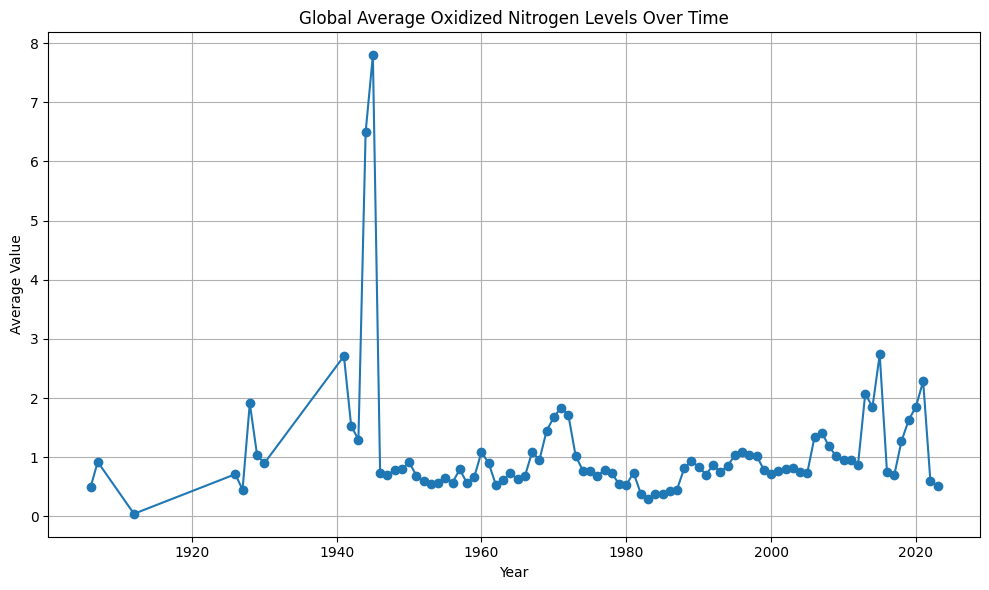

In [11]:
# Group by year to analyze global nitrogen pollution trends over time
# Convert 'Sample.Date' to datetime and extract the year into a new column
nitrate_df['Year'] = pd.to_datetime(nitrate_df['Sample.Date']).dt.year

# Calculate the global average oxidized nitrogen value for each year
trend = nitrate_df.groupby('Year')['Value'].mean().reset_index()

# Create a line chart to show the temporal trend of nitrogen pollution
plt.figure(figsize=(10,6))
plt.plot(trend['Year'], trend['Value'], marker='o')
plt.title('Global Average Oxidized Nitrogen Levels Over Time')
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
# for froggy, create csv (re-doing some of the code from above just to be extra cautious)

# Load the oxidized nitrogen data and station metadata from CSV files
nitrate_df = pd.read_csv('../data/oxidized_nitrogen.csv', sep=';', low_memory=False)
station_metadata = pd.read_csv('../data/GEMStat_station_metadata.csv', sep=';', encoding='ISO-8859-1')

# Clean column names by removing any leading/trailing whitespace
nitrate_df.columns = nitrate_df.columns.str.strip()
station_metadata.columns = station_metadata.columns.str.strip()

# Merge nitrate data with station metadata to enrich with country and station info
merged = pd.merge(
    nitrate_df,
    station_metadata,
    how='left',
    left_on='GEMS.Station.Number',
    right_on='GEMS Station Number'
)

# Convert 'Sample.Date' to datetime and 'Value' to numeric for analysis
merged['Sample.Date'] = pd.to_datetime(merged['Sample.Date'], errors='coerce')
merged['Value'] = pd.to_numeric(merged['Value'], errors='coerce')

# Remove rows missing key data: date, value, or country name
merged = merged.dropna(subset=['Country Name', 'Sample.Date', 'Value'])

# Extract year from the cleaned sample dates
merged['Year'] = merged['Sample.Date'].dt.year

# Group by Country and Year, calculating the average oxidized nitrogen level
summary = merged.groupby(['Country Name', 'Year'])['Value'].mean().reset_index()
summary.columns = ['Country', 'Year', 'Average Oxidized Nitrogen (mg/L)']

# Define a function to classify water quality based on nitrogen levels
def annotate_level(val):
    if val > 5:
        return 'High pollution, unsafe for drinking'
    elif val > 3:
        return 'Moderate to high pollution risk'
    else:
        return 'Low pollution, relatively clean water'

# Apply classification to each row in the summary table
summary['Notes'] = summary['Average Oxidized Nitrogen (mg/L)'].apply(annotate_level)

#  Save final CSV 
summary.to_csv('../data/oxidized_nitrogen_country_year.csv', index=False)
print("Saved to oxidized_nitrogen_country_year.csv")


Saved to oxidized_nitrogen_country_year.csv
